# Integrated Gradients, step by step

This notebook is the interactive companion to `ig_l1_simple.py`. We build
**Integrated Gradients (IG)** from scratch, one step at a time, and *verify*
it with IG's own correctness axiom.

## The one-sentence idea
> *"Which inputs made the model output what it did?"*

IG answers this by asking: as I slide each input from a boring **baseline** up
to its real value, how much does the output move? Inputs whose changes move the
output a lot get a large attribution; inputs that don't matter get ~0.

## The formula
For a model $f$, an input $x$, and a baseline $x'$ (the neutral reference):

$$
\mathrm{IG}_i(x) = (x_i - x'_i)\;\int_{0}^{1}
\frac{\partial f\big(x' + \alpha\,(x - x')\big)}{\partial x_i}\; d\alpha
$$

In words: walk the straight line from $x'$ to $x$. At many points on that path,
measure the gradient of the output w.r.t. input $i$. Average those gradients,
then scale by how far input $i$ had to travel, $(x_i - x'_i)$.

We approximate the integral with a sum over $M$ steps (a Riemann sum).

In [1]:
import torch
import matplotlib.pyplot as plt

torch.manual_seed(0)
N_STEPS = 64  # Riemann-sum resolution (number of points along the path)

## Step 1 — A tiny, transparent "model"

Instead of a black box, we use a function whose answer we can reason about:

$$ f(x) = x_0 \cdot x_1 + \sin(x_2) $$

We'll explain it at $x = [2, 3, 0]$ with baseline $x' = [0, 0, 0]$.

**What should IG say?**
- $x_0$ and $x_1$ multiply, so both should get a real, comparable attribution.
- $x_2$ enters as $\sin(x_2)$, but $x_2 = 0$ means it *never leaves the baseline* —
  so it should get ~0, even though its local gradient $\cos(0)=1$ is nonzero.

In [2]:
def f(x):
    """x has shape (batch, 3) -> returns (batch,)."""
    return x[:, 0] * x[:, 1] + torch.sin(x[:, 2])

x = torch.tensor([2.0, 3.0, 0.0])
baseline = torch.tensor([0.0, 0.0, 0.0])

fx = f(x.unsqueeze(0)).item()
fb = f(baseline.unsqueeze(0)).item()

print(f"f(x)  = {fx:.4f}")
print(f"f(x') = {fb:.4f}")
print(f"Output change to explain, f(x) - f(x') = {fx - fb:.4f}")

f(x)  = 6.0000
f(x') = 0.0000
Output change to explain, f(x) - f(x') = 6.0000


## Step 2 — Build the straight-line path from $x'$ to $x$

We pick $M$ interpolation fractions $\alpha \in [0, 1]$ and form

$$ \text{path}_k = x' + \alpha_k\,(x - x'). $$

We use the **midpoints** of each step ($\alpha_k = (k + 0.5)/M$) — the midpoint
rule is a more accurate Riemann sum than using the left or right edges.

In [3]:
alphas = (torch.arange(N_STEPS, dtype=torch.float32) + 0.5) / N_STEPS  # (M,)
delta = x - baseline                                  # (D,) distance each input travels
path = baseline.unsqueeze(0) + alphas.unsqueeze(1) * delta.unsqueeze(0)  # (M, D)
path.requires_grad_(True)

print("delta (how far each input travels):", delta.tolist())
print("path shape:", tuple(path.shape), "  (n_steps, n_features)")
print("first point :", path[0].detach().tolist())
print("last point  :", path[-1].detach().tolist())

delta (how far each input travels): [2.0, 3.0, 0.0]
path shape: (64, 3)   (n_steps, n_features)
first point : [0.015625, 0.0234375, 0.0]
last point  : [1.984375, 2.9765625, 0.0]


Let's *see* the path. Each input slides linearly from its baseline value to its
real value as $\alpha$ goes 0 → 1.

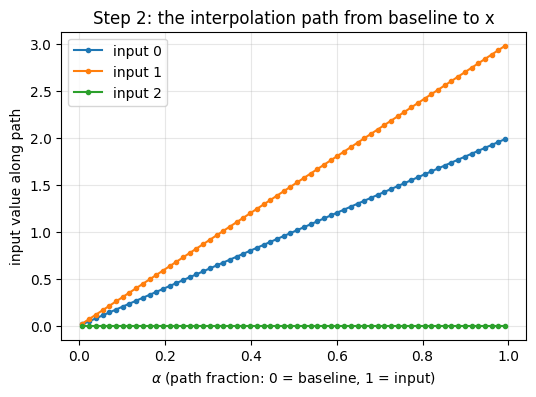

In [4]:
plt.figure(figsize=(6, 4))
for i in range(3):
    plt.plot(alphas.numpy(), path[:, i].detach().numpy(), marker='.', label=f"input {i}")
plt.xlabel(r"$\alpha$ (path fraction: 0 = baseline, 1 = input)")
plt.ylabel("input value along path")
plt.title("Step 2: the interpolation path from baseline to x")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Step 3 — Gradients at every point on the path

We do **one** forward pass over all $M$ path points and **one** backward pass.
Summing the outputs lets `.backward()` fill in $\partial(\text{out}_k)/\partial(\text{path}_k)$
for every $k$ at once — the cross terms are zero because output $k$ only depends
on path point $k$.

In [5]:
outputs = f(path)            # (M,)
outputs.sum().backward()
grads = path.grad            # (M, D) gradient at each point on the path

print("grads shape:", tuple(grads.shape))
print("gradient at first path point:", grads[0].tolist())
print("gradient at last  path point:", grads[-1].tolist())

grads shape: (64, 3)
gradient at first path point: [0.0234375, 0.015625, 1.0]
gradient at last  path point: [2.9765625, 1.984375, 1.0]


Watch how each input's gradient changes along the path. For $f = x_0 x_1 + \sin x_2$:
- $\partial f/\partial x_0 = x_1$, which *grows* as we move along the path (since $x_1$ ramps 0→3).
- $\partial f/\partial x_1 = x_0$, likewise ramps 0→2.
- $\partial f/\partial x_2 = \cos(x_2)$, but $x_2$ stays at 0, so it sits flat at $\cos(0)=1$.

IG integrates these curves — it's the **area under each gradient curve** that counts.

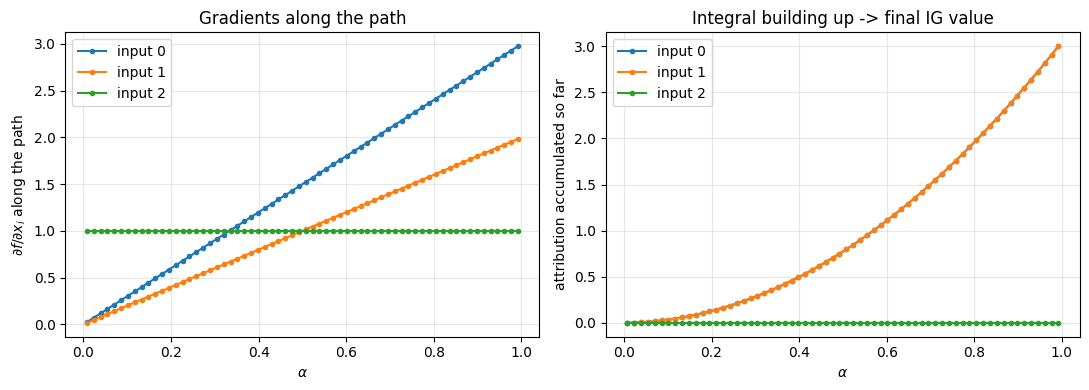

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))

for i in range(3):
    ax[0].plot(alphas.numpy(), grads[:, i].detach().numpy(), marker='.', label=f"input {i}")
ax[0].set_xlabel(r"$\alpha$")
ax[0].set_ylabel(r"$\partial f / \partial x_i$ along the path")
ax[0].set_title("Gradients along the path")
ax[0].legend(); ax[0].grid(alpha=0.3)

# Running (cumulative) integral scaled by delta = attribution built up so far.
cum = (delta * torch.cumsum(grads, dim=0) / N_STEPS).detach()
for i in range(3):
    ax[1].plot(alphas.numpy(), cum[:, i].numpy(), marker='.', label=f"input {i}")
ax[1].set_xlabel(r"$\alpha$")
ax[1].set_ylabel("attribution accumulated so far")
ax[1].set_title("Integral building up -> final IG value")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## Step 4 — Average the gradients, then scale by distance

$$ \mathrm{IG}_i = (x_i - x'_i)\cdot \underbrace{\frac{1}{M}\sum_k \frac{\partial f}{\partial x_i}\Big|_{\text{path}_k}}_{\text{average gradient}} $$

This is the whole method.

In [7]:
avg_grads = grads.mean(dim=0)          # (D,) approximates the integral
attributions = (delta * avg_grads).detach()

print("average gradient per input:", avg_grads.detach().tolist())
print()
for i, a in enumerate(attributions.tolist()):
    print(f"IG  input {i}: {a:+.4f}")

average gradient per input: [1.5, 1.0, 1.0]

IG  input 0: +3.0000
IG  input 1: +3.0000
IG  input 2: +0.0000


As predicted: $x_0$ and $x_1$ each get $+3.0$ (the product $x_0 x_1 = 6$ split
evenly), and $x_2$ gets $\approx 0$ because it never moved off the baseline.

## Step 5 — The completeness check (how we know it's right)

IG is *built* so the attributions add up to the change in output:

$$ \sum_i \mathrm{IG}_i(x) \;=\; f(x) - f(x') $$

If this doesn't hold (within Riemann-sum error), the implementation is wrong.

In [8]:
total = attributions.sum().item()
target = fx - fb
err = abs(total - target)

print(f"sum(attributions) = {total:.4f}")
print(f"f(x) - f(x')      = {target:.4f}")
print(f"difference        = {err:.6f}  (should be ~0)")
print("PASS" if err < 1e-2 else "FAIL - increase N_STEPS")

sum(attributions) = 6.0000
f(x) - f(x')      = 6.0000
difference        = 0.000000  (should be ~0)
PASS


## Step 6 — Why not just use the plain gradient at $x$?

A plain gradient is the **local** slope at $x$. Models *saturate*: near the
answer the slope can flatten to ~0 even for important inputs. Here the opposite
trap appears for input 2 — its local gradient $\cos(0)=1$ *suggests it matters*,
but it contributed nothing because it never moved. IG gets this right; the plain
gradient does not.

In [9]:
xg = x.clone().unsqueeze(0).requires_grad_(True)
f(xg).backward()
print("plain gradient at x:", xg.grad.squeeze().tolist())
print("integrated gradients:", attributions.tolist())
print()
print("Input 2: plain grad = 1.0 (misleading) vs IG = 0.0 (correct).")

plain gradient at x: [3.0, 2.0, 1.0]
integrated gradients: [3.0, 3.0, 0.0]

Input 2: plain grad = 1.0 (misleading) vs IG = 0.0 (correct).


## Things to experiment with

- Set `N_STEPS = 2` in the first cell, re-run, and watch the completeness error
  grow; then try `256`.
- Change `x` to `[2, 3, 1.5708]` ($x_2 = \pi/2$). Now $x_2$ travels through the
  $\sin$ curve and **should** earn a real attribution. Re-check completeness.
- Change the baseline to `[1, 1, 0]`: attributions change because IG always
  explains the output **relative to the baseline you choose**. Baseline choice
  matters a lot in practice.
- Replace `f()` with your own function and confirm completeness still holds.
- Swap the midpoint `alphas` for left-edge ones
  (`torch.arange(N_STEPS, dtype=torch.float32) / N_STEPS`) and watch the
  approximation get slightly worse for the same `N_STEPS`.

**Next:** `ig_l2` will apply this exact recipe to a real protein language model
(ESM-2), attributing a prediction back to individual amino-acid residues.